#1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

from xgboost import XGBClassifier

#2. Load Dataset

In [2]:
data = pd.read_csv("heart_disease_prediction_dataset.csv")

#3. Understand the Dataset

In [19]:
print(data.columns)
print("\n" + "═" * 128)
print("DATASET OVERVIEW - FIRST 5 ROWS".center(128))
print("═" * 128)
print(data.head())
print("\n" + "═" * 128)
print("Dataset Structure".center(128))
print("═" * 128)
data.info()
print("\n" + "═" * 128)
print("STATISTICAL SUMMARY".center(128))
print("═" * 128)
print(data.describe())

Index(['taking_bp_meds', 'taking_cholesterol_meds', 'age', 'sex',
       'race_ethnicity', 'education', 'poverty_income_ratio', 'taking_insulin',
       'taking_diabetes_pills', 'told_prediabetes', 'told_stroke',
       'family_history_heart_attack', 'diabetes', 'smoking_ever',
       'smoking_current', 'physically_active', 'hypertension',
       'high_cholesterol', 'heart_disease'],
      dtype='object')

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                DATASET OVERVIEW - FIRST 5 ROWS                                                 
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
   taking_bp_meds  taking_cholesterol_meds  ...  high_cholesterol  heart_disease
0               1                        0  ...                 0              0
1               1                        

In [29]:
data.nunique()

,0
taking_bp_meds,2
taking_cholesterol_meds,2
age,61
sex,2
race_ethnicity,6
education,5
poverty_income_ratio,431
taking_insulin,2
taking_diabetes_pills,2
told_prediabetes,2


In [36]:
print("Duplicates before:", data.duplicated().sum())

data = data.drop_duplicates()

print("Duplicates after:", data.duplicated().sum())
print("New shape:", data.shape)

Duplicates before: 58
Duplicates after: 0
New shape: (5510, 19)


#4. Feature_Target_Split

In [37]:
X = data.drop("heart_disease", axis=1)
y = data["heart_disease"]

In [38]:
print("Features : ", X.shape)
print("Target : ", y.shape)

Features :  (5510, 18)
Target :  (5510,)


#5. Train_Test_Split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [44]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4408
Testing samples: 1102


#6. Model Definition

In [45]:
model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)

#7. Training Zone

In [46]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

#8. Prediction Zone

In [47]:
y_pred = model.predict(X_test)

#9. Evaluation Zone

In [48]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

Accuracy: 0.8983666061705989
Precision: 0.3870967741935484
Recall: 0.11428571428571428
F1 Score: 0.17647058823529413
ROC AUC Score: 0.5476142713855853


In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95       997
           1       0.39      0.11      0.18       105

    accuracy                           0.90      1102
   macro avg       0.65      0.55      0.56      1102
weighted avg       0.86      0.90      0.87      1102



#10. Confusion matrix

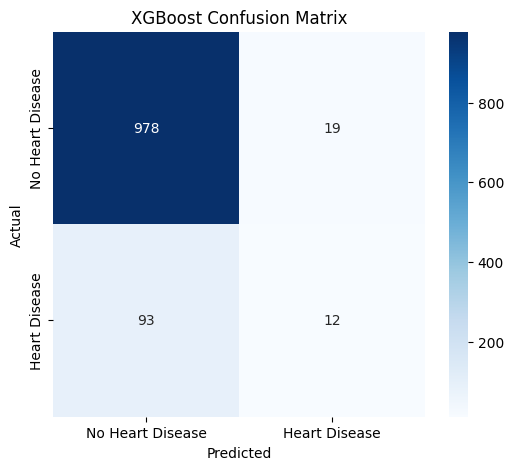

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

#11. ROC Curve

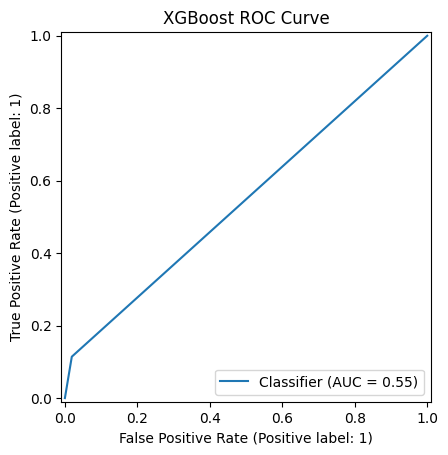

In [52]:
RocCurveDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("XGBoost ROC Curve")
plt.show()

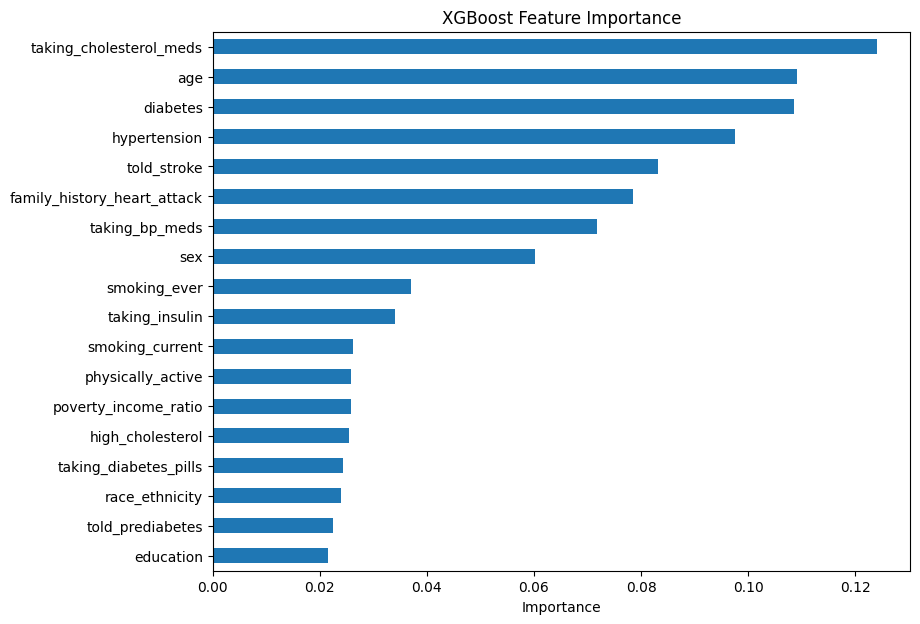

In [53]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9,7))

importance.plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.show()

In [54]:
import joblib

# Save model
joblib.dump(model, "xgboost_heart_disease_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [55]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

print(feature_names)

['taking_bp_meds', 'taking_cholesterol_meds', 'age', 'sex', 'race_ethnicity', 'education', 'poverty_income_ratio', 'taking_insulin', 'taking_diabetes_pills', 'told_prediabetes', 'told_stroke', 'family_history_heart_attack', 'diabetes', 'smoking_ever', 'smoking_current', 'physically_active', 'hypertension', 'high_cholesterol']
